
# 05 - Comparación puntual de los modelos candidatos

En sste notebook, se reúnen y se comparan las predicciones puntuales generadas por el modelo base ingenuo estacional, la regresión lineal, LightGBM y CatBoost.

El objetivo es disponer de una comparación clara y reproducible que utilice siempre el conjunto de validación y, en todo caso, distinguiendo entre:

- Las métricas calculadas con todas las observaciones evaluables de cada modelo
- Las métricas calculadas sobre los instantes objetivo comunes a todos los modelos (que constituyen la comparación más justa)
- Las figuras de diagnóstico pensadas para ilustrar la sección de resultados del documento



## Objetivos del notebook

1. Cargar las predicciones puntuales generadas en los notebooks 03, 04a, 04b y 04c
2. Resumir la disponibilidad de predicciones por modelo, horizonte y partición
3. Calcular las métricas MAE y RMSE en el conjunto de validación
4. Construir una comparación estrictamente homogénea sobre los instantes objetivo comunes
5. Medir la mejora relativa frente al modelo base ingenuo estacional
6. Generar tablas y figuras informativas para su posible utilización en la memoria
7. Analizar, de forma específica, el grado de desacuerdo entre LightGBM y CatBoost


In [1]:

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error



## Configuración general

En esta sección se localiza la raíz del proyecto, se definen las carpetas de entrada/salida y se registran los modelos que se van a comparar.


In [2]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "reports").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Ejecuta el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_PREDICTIONS_DIR = PROJECT_ROOT / "reports" / "predictions"

for path in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR, REPORTS_PREDICTIONS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

HORIZONS: List[int] = [1, 4, 12, 24]
VALIDATION_SPLIT = "validation"
EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 14 * 24

MODEL_REGISTRY: Dict[str, Dict[str, str]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "file_prefix": "baseline_seasonal_naive",
        "color": "tab:orange",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "file_prefix": "linear_regression",
        "color": "tab:green",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "file_prefix": "lightgbm",
        "color": "tab:red",
    },
    "catboost": {
        "display_name": "CatBoost",
        "file_prefix": "catboost",
        "color": "tab:purple",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
OBSERVED_COLOR = "tab:blue"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Predicciones: {REPORTS_PREDICTIONS_DIR}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")


Raíz del proyecto: c:\trabajo_github
Predicciones: c:\trabajo_github\reports\predictions
Tablas: c:\trabajo_github\reports\tables
Figuras: c:\trabajo_github\reports\figures



## Carga de las predicciones puntuales

Se cargan los archivos que contienen las predicciones puntuales generadas en los notebooks previos. Cada fila representa una predicción asociada a un instante objetivo concreto y a un horizonte de predicción determinado.


In [3]:

REQUIRED_PREDICTION_COLUMNS = {
    "horizon",
    "split",
    "origin_timestamp",
    "target_timestamp",
    "y_true",
    "y_pred",
}


def load_model_predictions(model_id: str, horizon: int) -> pd.DataFrame:
    """Carga las predicciones guardadas para un modelo y horizonte concretos."""
    file_prefix = MODEL_REGISTRY[model_id]["file_prefix"]
    file_path = REPORTS_PREDICTIONS_DIR / f"{file_prefix}_h{horizon:02d}.parquet"

    if not file_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {file_path}. Debe ejecutarse primero el notebook "
            f"correspondiente al modelo {model_id}."
        )

    pred = pd.read_parquet(file_path).copy()

    missing_columns = REQUIRED_PREDICTION_COLUMNS.difference(pred.columns)
    if missing_columns:
        raise ValueError(
            f"El archivo {file_path} no contiene las columnas esperadas: "
            f"{sorted(missing_columns)}"
        )

    pred["model"] = model_id
    pred["model_display"] = MODEL_REGISTRY[model_id]["display_name"]
    pred["horizon"] = int(horizon)

    pred["origin_timestamp"] = pd.to_datetime(pred["origin_timestamp"])
    pred["target_timestamp"] = pd.to_datetime(pred["target_timestamp"])

    # Una predicción es evaluable si están disponibles tanto el valor real como la predicción.
    pred["is_evaluable"] = pred["y_true"].notna() & pred["y_pred"].notna()
    pred["residual"] = pred["y_true"] - pred["y_pred"]
    pred["abs_error"] = pred["residual"].abs()
    pred["squared_error"] = pred["residual"] ** 2

    return pred


prediction_frames: list[pd.DataFrame] = []

for model_id in MODEL_ORDER:
    for horizon in HORIZONS:
        pred_h = load_model_predictions(model_id, horizon)
        prediction_frames.append(pred_h)

all_predictions = pd.concat(prediction_frames, ignore_index=True)
all_predictions = all_predictions.sort_values(
    ["model", "horizon", "split", "target_timestamp"]
).reset_index(drop=True)

print(f"Total de filas cargadas: {len(all_predictions):,}")
display(all_predictions.head())


Total de filas cargadas: 169,420


,horizon,split,origin_timestamp,target_timestamp,y_true,y_pred,model,baseline_rule,baseline_source_timestamp,source_lag_from_origin_h,is_evaluable,residual,abs_error,squared_error,model_display
0,1,calibration,2022-12-31 23:00:00,2023-01-01 00:00:00,1.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 00:00:00,23.000,True,-16.000,16.000,256.000,Modelo base ingenuo estacional
1,1,calibration,2023-01-01 00:00:00,2023-01-01 01:00:00,1.000,25.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 01:00:00,23.000,True,-24.000,24.000,576.000,Modelo base ingenuo estacional
2,1,calibration,2023-01-01 01:00:00,2023-01-01 02:00:00,1.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 02:00:00,23.000,True,-16.000,16.000,256.000,Modelo base ingenuo estacional
3,1,calibration,2023-01-01 02:00:00,2023-01-01 03:00:00,1.000,32.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 03:00:00,23.000,True,-31.000,31.000,961.000,Modelo base ingenuo estacional
4,1,calibration,2023-01-01 03:00:00,2023-01-01 04:00:00,1.000,46.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 04:00:00,23.000,True,-45.000,45.000,"2,025.000",Modelo base ingenuo estacional



## Verificación de la disponibilidad de las predicciones

Antes de comparar métricas, conviene verificar cuántas observaciones evaluables aporta cada modelo en cada partición y horizonte. Por tanto, esta tabla funciona como control de calidad del pipeline.


In [4]:


def summarize_prediction_availability(predictions: pd.DataFrame) -> pd.DataFrame:
    """Resume la disponibilidad de predicciones por modelo, horizonte y split."""
    rows = []

    for (model_id, horizon, split), group in predictions.groupby(
        ["model", "horizon", "split"], sort=True
    ):
        valid_mask = group["is_evaluable"]

        rows.append(
            {
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "horizon": int(horizon),
                "split": split,
                "n_rows": int(len(group)),
                "n_evaluable": int(valid_mask.sum()),
                "target_start": group["target_timestamp"].min(),
                "target_end": group["target_timestamp"].max(),
                "missing_y_pct": float(group["y_true"].isna().mean() * 100),
                "missing_pred_pct": float(group["y_pred"].isna().mean() * 100),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["split", "horizon", "model"])
        .reset_index(drop=True)
    )


prediction_availability_df = summarize_prediction_availability(all_predictions)
display(prediction_availability_df)


,model,model_display,horizon,split,n_rows,n_evaluable,target_start,target_end,missing_y_pct,missing_pred_pct
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
1,baseline_seasonal_naive,Modelo base ingenuo estacional,4,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
2,baseline_seasonal_naive,Modelo base ingenuo estacional,12,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
3,baseline_seasonal_naive,Modelo base ingenuo estacional,24,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
4,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.000,2.039
5,catboost,CatBoost,1,validation,8437,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000
6,lightgbm,LightGBM,1,validation,8437,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000
7,linear_regression,Regresión lineal,1,validation,8437,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000
8,baseline_seasonal_naive,Modelo base ingenuo estacional,4,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.000,2.039
9,catboost,CatBoost,4,validation,8437,8437,2024-01-01,2024-12-31 23:00:00,0.000,0.000



## Métricas en el conjunto de validación considerando todas las observaciones evaluables

Esta primera comparación utiliza, para cada modelo, todas las observaciones del conjunto de validación en las que existe valor real y predicción. Más adelante, se construirá una comparación aún más estricta.


In [5]:
def compute_point_metrics(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> dict:
    """Calcula MAE, RMSE y algunos diagnósticos adicionales."""
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)
    residuals = y_true_array - y_pred_array

    return {
        "mae": float(mean_absolute_error(y_true_array, y_pred_array)),
        "rmse": float(np.sqrt(mean_squared_error(y_true_array, y_pred_array))),
        "mean_error": float(np.mean(residuals)),
        "median_abs_error": float(np.median(np.abs(residuals))),
        "n_negative_predictions": int(np.sum(y_pred_array < 0)),
    }

def compute_available_validation_metrics(predictions: pd.DataFrame) -> pd.DataFrame:
    """Calcula métricas en validación usando todas las filas evaluables de cada modelo."""
    validation = predictions.loc[predictions["split"] == VALIDATION_SPLIT].copy()
    rows = []

    for (model_id, horizon), group in validation.groupby(["model", "horizon"], sort=True):
        valid = group.loc[group["is_evaluable"]].copy()

        row = {
            "model": model_id,
            "model_display": MODEL_REGISTRY[model_id]["display_name"],
            "horizon": int(horizon),
            "n_available": int(len(valid)),
            "target_start": valid["target_timestamp"].min() if not valid.empty else pd.NaT,
            "target_end": valid["target_timestamp"].max() if not valid.empty else pd.NaT,
        }

        if valid.empty:
            row.update({
                "mae": np.nan,
                "rmse": np.nan,
                "mean_error": np.nan,
                "median_abs_error": np.nan,
                "n_negative_predictions": np.nan,
            })
        else:
            row.update(compute_point_metrics(valid["y_true"], valid["y_pred"]))

        rows.append(row)

    return pd.DataFrame(rows).sort_values(["horizon", "model"]).reset_index(drop=True)

available_metrics_df = compute_available_validation_metrics(all_predictions)
display(available_metrics_df)


,model,model_display,horizon,n_available,target_start,target_end,mae,rmse,mean_error,median_abs_error,n_negative_predictions
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0
1,catboost,CatBoost,1,8437,2024-01-01,2024-12-31 23:00:00,6.251,8.563,0.474,4.547,14
2,lightgbm,LightGBM,1,8437,2024-01-01,2024-12-31 23:00:00,6.259,8.587,0.502,4.569,0
3,linear_regression,Regresión lineal,1,8437,2024-01-01,2024-12-31 23:00:00,6.624,9.043,0.298,4.909,20
4,baseline_seasonal_naive,Modelo base ingenuo estacional,4,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0
5,catboost,CatBoost,4,8437,2024-01-01,2024-12-31 23:00:00,11.522,14.623,1.732,9.583,15
6,lightgbm,LightGBM,4,8437,2024-01-01,2024-12-31 23:00:00,11.577,14.729,1.534,9.610,0
7,linear_regression,Regresión lineal,4,8437,2024-01-01,2024-12-31 23:00:00,12.628,15.950,1.219,10.479,34
8,baseline_seasonal_naive,Modelo base ingenuo estacional,12,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0
9,catboost,CatBoost,12,8437,2024-01-01,2024-12-31 23:00:00,13.540,16.952,3.069,11.426,0



## Comparación justa sobre los instantes objetivo comunes a todos los modelos

Para comparar los modelos de forma totalmente homogénea, se identifican los instantes objetivo de validación compartidos por todos los modelos. A partir de ellos, se recalculan las métricas MAE y RMSE.


In [6]:
def get_validation_evaluable(predictions: pd.DataFrame, model_id: str, horizon: int) -> pd.DataFrame:
    """Devuelve las predicciones evaluables de validación para un modelo y horizonte."""
    subset = predictions.loc[
        (predictions["model"] == model_id)
        & (predictions["horizon"] == horizon)
        & (predictions["split"] == VALIDATION_SPLIT)
        & (predictions["is_evaluable"])
    ].copy()

    duplicated_targets = subset["target_timestamp"].duplicated().sum()
    if duplicated_targets:
        duplicated_values = subset.loc[
            subset["target_timestamp"].duplicated(), "target_timestamp"
        ].head().tolist()
        raise ValueError(
            f"Existen target_timestamp duplicados para {model_id}, h={horizon}: "
            f"{duplicated_values}"
        )

    return subset.sort_values("target_timestamp").reset_index(drop=True)

def build_common_target_sets(predictions: pd.DataFrame) -> tuple[dict[int, set[pd.Timestamp]], pd.DataFrame]:
    """Calcula los "target_timestamp" comunes a todos los modelos por horizonte."""
    common_targets_by_horizon: dict[int, set[pd.Timestamp]] = {}
    overlap_rows = []

    for horizon in HORIZONS:
        targets_by_model: dict[str, set[pd.Timestamp]] = {}

        for model_id in MODEL_ORDER:
            valid = get_validation_evaluable(predictions, model_id, horizon)
            targets_by_model[model_id] = set(valid["target_timestamp"])

        common_targets = set.intersection(*targets_by_model.values())
        common_targets_by_horizon[horizon] = common_targets

        for model_id in MODEL_ORDER:
            n_available = len(targets_by_model[model_id])
            n_common = len(common_targets)
            overlap_rows.append(
                {
                    "model": model_id,
                    "model_display": MODEL_REGISTRY[model_id]["display_name"],
                    "horizon": horizon,
                    "n_available_validation_targets": n_available,
                    "n_common_validation_targets": n_common,
                    "common_pct_of_available": float(n_common / n_available * 100) if n_available else np.nan,
                }
            )

    overlap_df = pd.DataFrame(overlap_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
    return common_targets_by_horizon, overlap_df

def compute_common_validation_metrics(
    predictions: pd.DataFrame,
    common_targets_by_horizon: dict[int, set[pd.Timestamp]],
) -> pd.DataFrame:
    """Calcula métricas en validación sobre los instantes objetivo comunes."""
    rows = []

    for horizon in HORIZONS:
        common_targets = common_targets_by_horizon[horizon]

        for model_id in MODEL_ORDER:
            valid = get_validation_evaluable(predictions, model_id, horizon)
            valid = valid.loc[valid["target_timestamp"].isin(common_targets)].copy()

            row = {
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "horizon": horizon,
                "n_common": int(len(valid)),
                "target_start": valid["target_timestamp"].min() if not valid.empty else pd.NaT,
                "target_end": valid["target_timestamp"].max() if not valid.empty else pd.NaT,
            }

            if valid.empty:
                row.update({
                    "mae": np.nan,
                    "rmse": np.nan,
                    "mean_error": np.nan,
                    "median_abs_error": np.nan,
                    "n_negative_predictions": np.nan,
                })
            else:
                row.update(compute_point_metrics(valid["y_true"], valid["y_pred"]))

            rows.append(row)

    return pd.DataFrame(rows).sort_values(["horizon", "model"]).reset_index(drop=True)

common_targets_by_horizon, overlap_summary_df = build_common_target_sets(all_predictions)
common_metrics_df = compute_common_validation_metrics(all_predictions, common_targets_by_horizon)

display(overlap_summary_df)
display(common_metrics_df)


,model,model_display,horizon,n_available_validation_targets,n_common_validation_targets,common_pct_of_available
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,8265,8265,100.000
1,catboost,CatBoost,1,8437,8265,97.961
2,lightgbm,LightGBM,1,8437,8265,97.961
3,linear_regression,Regresión lineal,1,8437,8265,97.961
4,baseline_seasonal_naive,Modelo base ingenuo estacional,4,8265,8265,100.000
5,catboost,CatBoost,4,8437,8265,97.961
6,lightgbm,LightGBM,4,8437,8265,97.961
7,linear_regression,Regresión lineal,4,8437,8265,97.961
8,baseline_seasonal_naive,Modelo base ingenuo estacional,12,8265,8265,100.000
9,catboost,CatBoost,12,8437,8265,97.961


,model,model_display,horizon,n_common,target_start,target_end,mae,rmse,mean_error,median_abs_error,n_negative_predictions
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0
1,catboost,CatBoost,1,8265,2024-01-01,2024-12-31 23:00:00,6.279,8.600,0.443,4.571,14
2,lightgbm,LightGBM,1,8265,2024-01-01,2024-12-31 23:00:00,6.286,8.622,0.485,4.585,0
3,linear_regression,Regresión lineal,1,8265,2024-01-01,2024-12-31 23:00:00,6.640,9.069,0.277,4.916,20
4,baseline_seasonal_naive,Modelo base ingenuo estacional,4,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0
5,catboost,CatBoost,4,8265,2024-01-01,2024-12-31 23:00:00,11.576,14.691,1.677,9.611,15
6,lightgbm,LightGBM,4,8265,2024-01-01,2024-12-31 23:00:00,11.618,14.787,1.493,9.627,0
7,linear_regression,Regresión lineal,4,8265,2024-01-01,2024-12-31 23:00:00,12.648,15.984,1.166,10.478,34
8,baseline_seasonal_naive,Modelo base ingenuo estacional,12,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0
9,catboost,CatBoost,12,8265,2024-01-01,2024-12-31 23:00:00,13.601,17.022,2.981,11.486,0



## Comprobación de la coherencia del valor observado

Dado que el valor real debería ser el mismo para un mismo instante objetivo, esta comprobación confirma que no existan discrepancias en la columna `y_true` al cruzar modelos sobre los mismos objetivos de validación.


In [7]:
def check_target_consistency(
    predictions: pd.DataFrame,
    common_targets_by_horizon: dict[int, set[pd.Timestamp]],
) -> pd.DataFrame:
    """Comprueba que y_true coincida para todos los modelos en los instantes objetivo comunes."""
    rows = []

    for horizon in HORIZONS:
        values_per_model = []

        for model_id in MODEL_ORDER:
            valid = get_validation_evaluable(predictions, model_id, horizon)
            valid = valid.loc[valid["target_timestamp"].isin(common_targets_by_horizon[horizon])].copy()
            valid = valid[["target_timestamp", "y_true"]].rename(columns={"y_true": f"y_true_{model_id}"})
            values_per_model.append(valid)

        merged = values_per_model[0]
        for df in values_per_model[1:]:
            merged = merged.merge(df, on="target_timestamp", how="inner")

        reference_col = merged.columns[1]
        max_abs_diff = 0.0

        for col in merged.columns[2:]:
            diff = (merged[col] - merged[reference_col]).abs().max()
            max_abs_diff = max(max_abs_diff, float(diff))

        rows.append(
            {
                "horizon": horizon,
                "n_common_targets": int(len(merged)),
                "max_abs_diff_y_true": max_abs_diff,
                "is_consistent": bool(max_abs_diff < 1e-12),
            }
        )

    return pd.DataFrame(rows)


target_consistency_df = check_target_consistency(all_predictions, common_targets_by_horizon)
display(target_consistency_df)


,horizon,n_common_targets,max_abs_diff_y_true,is_consistent
0,1,8265,0.000,True
1,4,8265,0.000,True
2,12,8265,0.000,True
3,24,8265,0.000,True



## Tablas-resumen para la memoria

Se generan varias tablas derivadas de la validación que facilitarán la descripción de esta fase en la memoria: métricas en formato ancho, mejora relativa frente al modelo base ingenuo estacional y modelo mejor posicionado por horizonte.


In [8]:
def build_metric_pivots(common_metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Crea tablas anchas separadas para MAE y RMSE."""
    mae_wide = (
        common_metrics
        .pivot(index="horizon", columns="model_display", values="mae")
        .sort_index()
        .reset_index()
    )

    rmse_wide = (
        common_metrics
        .pivot(index="horizon", columns="model_display", values="rmse")
        .sort_index()
        .reset_index()
    )

    return mae_wide, rmse_wide

def compute_improvement_vs_baseline(common_metrics: pd.DataFrame) -> pd.DataFrame:
    """Calcula la mejora relativa de cada modelo respecto al modelo base."""
    baseline = common_metrics.loc[
        common_metrics["model"] == "baseline_seasonal_naive",
        ["horizon", "mae", "rmse"],
    ].rename(columns={"mae": "baseline_mae", "rmse": "baseline_rmse"})

    merged = common_metrics.merge(baseline, on="horizon", how="left")
    merged["mae_improvement_pct_vs_baseline"] = (
        (merged["baseline_mae"] - merged["mae"]) / merged["baseline_mae"] * 100
    )
    merged["rmse_improvement_pct_vs_baseline"] = (
        (merged["baseline_rmse"] - merged["rmse"]) / merged["baseline_rmse"] * 100
    )
    return merged.sort_values(["horizon", "model"]).reset_index(drop=True)

def select_best_model_by_horizon(common_metrics: pd.DataFrame) -> pd.DataFrame:
    """Selecciona el modelo con mejor MAE y RMSE para cada horizonte."""
    rows = []

    for horizon, group in common_metrics.groupby("horizon", sort=True):
        best_mae_row = group.loc[group["mae"].idxmin()]
        best_rmse_row = group.loc[group["rmse"].idxmin()]
        rows.append(
            {
                "horizon": int(horizon),
                "best_model_mae": best_mae_row["model"],
                "best_model_mae_display": best_mae_row["model_display"],
                "best_mae": float(best_mae_row["mae"]),
                "best_model_rmse": best_rmse_row["model"],
                "best_model_rmse_display": best_rmse_row["model_display"],
                "best_rmse": float(best_rmse_row["rmse"]),
            }
        )

    return pd.DataFrame(rows).sort_values("horizon").reset_index(drop=True)

mae_wide_df, rmse_wide_df = build_metric_pivots(common_metrics_df)
improvement_df = compute_improvement_vs_baseline(common_metrics_df)
best_point_models_df = select_best_model_by_horizon(common_metrics_df)

print("Tabla ancha de MAE:")
display(mae_wide_df.round(3))

print("Tabla ancha de RMSE:")
display(rmse_wide_df.round(3))

print("Mejora relativa frente al modelo base:")
display(improvement_df.round(3))

print("Modelo mejor posicionado por horizonte:")
display(best_point_models_df.round(3))


Tabla ancha de MAE:


model_display,horizon,CatBoost,LightGBM,Modelo base ingenuo estacional,Regresión lineal
0,1,6.279,6.286,16.664,6.640
1,4,11.576,11.618,16.664,12.648
2,12,13.601,13.654,16.664,14.128
3,24,13.990,14.056,16.664,14.513


Tabla ancha de RMSE:


model_display,horizon,CatBoost,LightGBM,Modelo base ingenuo estacional,Regresión lineal
0,1,8.600,8.622,21.848,9.069
1,4,14.691,14.787,21.848,15.984
2,12,17.022,17.092,21.848,17.672
3,24,17.464,17.608,21.848,18.056


Mejora relativa frente al modelo base:


,model,model_display,horizon,n_common,target_start,target_end,mae,rmse,mean_error,median_abs_error,n_negative_predictions,baseline_mae,baseline_rmse,mae_improvement_pct_vs_baseline,rmse_improvement_pct_vs_baseline
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0,16.664,21.848,0.000,0.000
1,catboost,CatBoost,1,8265,2024-01-01,2024-12-31 23:00:00,6.279,8.600,0.443,4.571,14,16.664,21.848,62.321,60.639
2,lightgbm,LightGBM,1,8265,2024-01-01,2024-12-31 23:00:00,6.286,8.622,0.485,4.585,0,16.664,21.848,62.280,60.534
3,linear_regression,Regresión lineal,1,8265,2024-01-01,2024-12-31 23:00:00,6.640,9.069,0.277,4.916,20,16.664,21.848,60.154,58.492
4,baseline_seasonal_naive,Modelo base ingenuo estacional,4,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0,16.664,21.848,0.000,0.000
5,catboost,CatBoost,4,8265,2024-01-01,2024-12-31 23:00:00,11.576,14.691,1.677,9.611,15,16.664,21.848,30.530,32.758
6,lightgbm,LightGBM,4,8265,2024-01-01,2024-12-31 23:00:00,11.618,14.787,1.493,9.627,0,16.664,21.848,30.282,32.318
7,linear_regression,Regresión lineal,4,8265,2024-01-01,2024-12-31 23:00:00,12.648,15.984,1.166,10.478,34,16.664,21.848,24.100,26.840
8,baseline_seasonal_naive,Modelo base ingenuo estacional,12,8265,2024-01-01,2024-12-31 23:00:00,16.664,21.848,-0.065,13.000,0,16.664,21.848,0.000,0.000
9,catboost,CatBoost,12,8265,2024-01-01,2024-12-31 23:00:00,13.601,17.022,2.981,11.486,0,16.664,21.848,18.379,22.088


Modelo mejor posicionado por horizonte:


,horizon,best_model_mae,best_model_mae_display,best_mae,best_model_rmse,best_model_rmse_display,best_rmse
0,1,catboost,CatBoost,6.279,catboost,CatBoost,8.600
1,4,catboost,CatBoost,11.576,catboost,CatBoost,14.691
2,12,catboost,CatBoost,13.601,catboost,CatBoost,17.022
3,24,catboost,CatBoost,13.990,catboost,CatBoost,17.464



## Diagnóstico específico: LightGBM frente a CatBoost

Aunque tanto LightGBM como CatBoost presentan métricas globales parecidas, debe comprobarse cuánto difieren en sus predicciones, pues podría resultar fundamental para seleccionar el modelo ganador. La siguiente tabla resume el desacuerdo entre ambas series de predicción.


In [9]:


def compare_lightgbm_catboost_predictions(predictions: pd.DataFrame) -> pd.DataFrame:
    """Compara, directamente, las predicciones de LightGBM y CatBoost."""
    rows = []

    for horizon in HORIZONS:
        lgbm = get_validation_evaluable(predictions, "lightgbm", horizon)[
            ["horizon", "target_timestamp", "y_true", "y_pred"]
        ].rename(columns={"y_pred": "y_pred_lightgbm"})

        cat = get_validation_evaluable(predictions, "catboost", horizon)[
            ["horizon", "target_timestamp", "y_true", "y_pred"]
        ].rename(columns={"y_pred": "y_pred_catboost"})

        merged = lgbm.merge(
            cat,
            on=["horizon", "target_timestamp", "y_true"],
            how="inner",
        )

        diff = merged["y_pred_lightgbm"] - merged["y_pred_catboost"]

        rows.append(
            {
                "horizon": horizon,
                "n_common_predictions": int(len(merged)),
                "mean_abs_diff": float(diff.abs().mean()),
                "median_abs_diff": float(diff.abs().median()),
                "max_abs_diff": float(diff.abs().max()),
                "corr_predictions": float(merged["y_pred_lightgbm"].corr(merged["y_pred_catboost"])),
                "exactly_equal_predictions": bool((diff.abs() < 1e-12).all()),
            }
        )

    return pd.DataFrame(rows).sort_values("horizon").reset_index(drop=True)


lightgbm_catboost_comparison_df = compare_lightgbm_catboost_predictions(all_predictions)
display(lightgbm_catboost_comparison_df.round(4))


,horizon,n_common_predictions,mean_abs_diff,median_abs_diff,max_abs_diff,corr_predictions,exactly_equal_predictions
0,1,8437,0.905,0.713,19.045,0.999,False
1,4,8437,1.731,1.373,18.798,0.994,False
2,12,8437,1.994,1.598,12.859,0.990,False
3,24,8437,2.173,1.718,14.552,0.988,False



## Guardado de las tablas

Todas las tablas relevantes se guardan en `reports/tables` para facilitar su reutilización en notebooks posteriores.


In [10]:

availability_path = REPORTS_TABLES_DIR / "point_prediction_availability.csv"
available_metrics_path = REPORTS_TABLES_DIR / "point_metrics_validation_available.csv"
overlap_summary_path = REPORTS_TABLES_DIR / "point_prediction_overlap_summary.csv"
common_metrics_path = REPORTS_TABLES_DIR / "point_metrics_validation_common.csv"
mae_wide_path = REPORTS_TABLES_DIR / "point_metrics_validation_common_mae_wide.csv"
rmse_wide_path = REPORTS_TABLES_DIR / "point_metrics_validation_common_rmse_wide.csv"
target_consistency_path = REPORTS_TABLES_DIR / "point_target_consistency_check.csv"
improvement_path = REPORTS_TABLES_DIR / "point_improvement_vs_baseline.csv"
best_models_path = REPORTS_TABLES_DIR / "point_best_model_by_horizon.csv"
lgbm_catboost_comparison_path = REPORTS_TABLES_DIR / "lightgbm_catboost_prediction_comparison.csv"

prediction_availability_df.to_csv(availability_path, index=False)
available_metrics_df.to_csv(available_metrics_path, index=False)
overlap_summary_df.to_csv(overlap_summary_path, index=False)
common_metrics_df.to_csv(common_metrics_path, index=False)
mae_wide_df.to_csv(mae_wide_path, index=False)
rmse_wide_df.to_csv(rmse_wide_path, index=False)
target_consistency_df.to_csv(target_consistency_path, index=False)
improvement_df.to_csv(improvement_path, index=False)
best_point_models_df.to_csv(best_models_path, index=False)
lightgbm_catboost_comparison_df.to_csv(lgbm_catboost_comparison_path, index=False)

for path in [
    availability_path,
    available_metrics_path,
    overlap_summary_path,
    common_metrics_path,
    mae_wide_path,
    rmse_wide_path,
    target_consistency_path,
    improvement_path,
    best_models_path,
    lgbm_catboost_comparison_path,
]:
    print(f"Guardado: {path}")


Guardado: c:\trabajo_github\reports\tables\point_prediction_availability.csv
Guardado: c:\trabajo_github\reports\tables\point_metrics_validation_available.csv
Guardado: c:\trabajo_github\reports\tables\point_prediction_overlap_summary.csv
Guardado: c:\trabajo_github\reports\tables\point_metrics_validation_common.csv
Guardado: c:\trabajo_github\reports\tables\point_metrics_validation_common_mae_wide.csv
Guardado: c:\trabajo_github\reports\tables\point_metrics_validation_common_rmse_wide.csv
Guardado: c:\trabajo_github\reports\tables\point_target_consistency_check.csv
Guardado: c:\trabajo_github\reports\tables\point_improvement_vs_baseline.csv
Guardado: c:\trabajo_github\reports\tables\point_best_model_by_horizon.csv
Guardado: c:\trabajo_github\reports\tables\lightgbm_catboost_prediction_comparison.csv



## Figura 1 - Comparación global de las métricas MAE y RMSE

Esta figura resume el rendimiento puntual de todos los modelos para una validación común. Es decir, muestra de forma compacta cómo varía el error en función del horizonte.


Figura guardada en: c:\trabajo_github\reports\figures\fig_point_metrics_validation_common.png


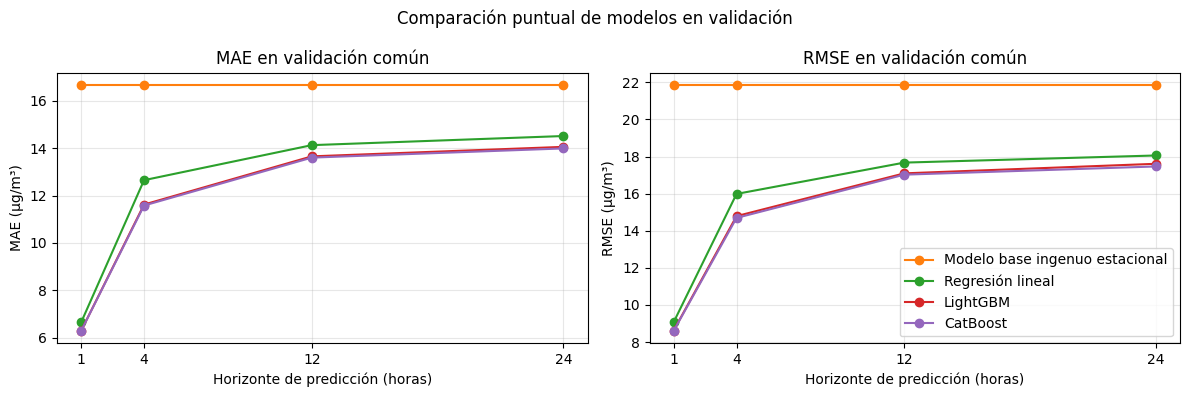

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for model_id in MODEL_ORDER:
    model_df = common_metrics_df.loc[common_metrics_df["model"] == model_id].sort_values("horizon")
    label = MODEL_REGISTRY[model_id]["display_name"]
    color = MODEL_REGISTRY[model_id]["color"]

    axes[0].plot(model_df["horizon"], model_df["mae"], marker="o", label=label, color=color)
    axes[1].plot(model_df["horizon"], model_df["rmse"], marker="o", label=label, color=color)

axes[0].set_title("MAE en validación común")
axes[0].set_xlabel("Horizonte de predicción (horas)")
axes[0].set_ylabel("MAE (µg/m³)")
axes[0].set_xticks(HORIZONS)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("RMSE en validación común")
axes[1].set_xlabel("Horizonte de predicción (horas)")
axes[1].set_ylabel("RMSE (µg/m³)")
axes[1].set_xticks(HORIZONS)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

fig.suptitle("Comparación puntual de modelos en validación")
fig.tight_layout()

metrics_figure_path = REPORTS_FIGURES_DIR / "fig_point_metrics_validation_common.png"
fig.savefig(metrics_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {metrics_figure_path}")
plt.show()



## Figura 2 - Mejora relativa frente al modelo base

Esta figura ayuda a cuantificar cuánto mejora cada modelo de aprendizaje automático respecto al modelo base ingenuo estacional.


Figura guardada en: c:\trabajo_github\reports\figures\fig_point_improvement_vs_baseline.png


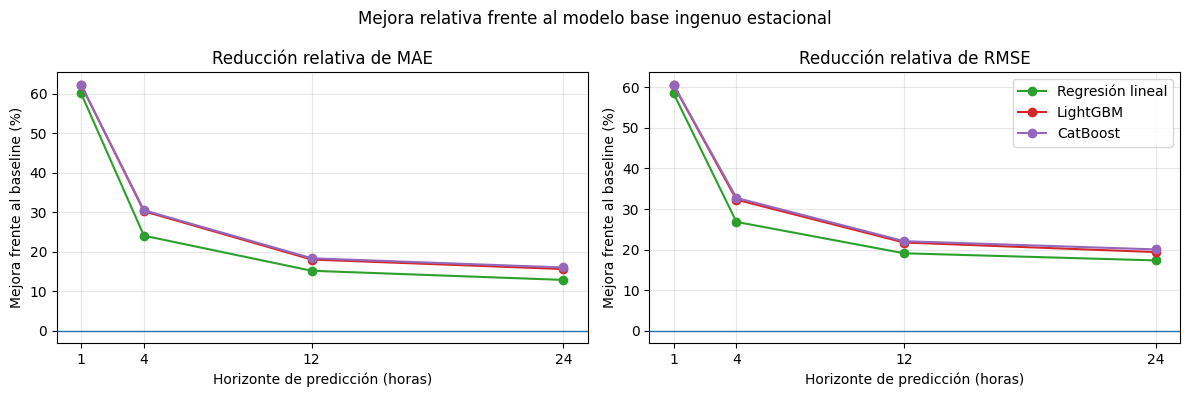

In [12]:
improvement_plot_df = improvement_df.loc[
    improvement_df["model"] != "baseline_seasonal_naive"
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for model_id in ["linear_regression", "lightgbm", "catboost"]:
    model_df = improvement_plot_df.loc[improvement_plot_df["model"] == model_id].sort_values("horizon")
    label = MODEL_REGISTRY[model_id]["display_name"]
    color = MODEL_REGISTRY[model_id]["color"]

    axes[0].plot(
        model_df["horizon"],
        model_df["mae_improvement_pct_vs_baseline"],
        marker="o",
        label=label,
        color=color,
    )
    axes[1].plot(
        model_df["horizon"],
        model_df["rmse_improvement_pct_vs_baseline"],
        marker="o",
        label=label,
        color=color,
    )

axes[0].axhline(0, linewidth=1)
axes[1].axhline(0, linewidth=1)

axes[0].set_title("Reducción relativa de MAE")
axes[0].set_xlabel("Horizonte de predicción (horas)")
axes[0].set_ylabel("Mejora frente al baseline (%)")
axes[0].set_xticks(HORIZONS)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Reducción relativa de RMSE")
axes[1].set_xlabel("Horizonte de predicción (horas)")
axes[1].set_ylabel("Mejora frente al baseline (%)")
axes[1].set_xticks(HORIZONS)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

fig.suptitle("Mejora relativa frente al modelo base ingenuo estacional")
fig.tight_layout()

improvement_figure_path = REPORTS_FIGURES_DIR / "fig_point_improvement_vs_baseline.png"
fig.savefig(improvement_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {improvement_figure_path}")
plt.show()



## Selección de un tramo continuo para una inspección visual

Las siguientes figuras utilizan un bloque continuo del conjunto de validación para el horizonte elegido. Se trabaja sobre los instantes objetivo comunes para que todas las curvas sean comparables entre sí.


In [13]:
def build_common_wide_predictions(
    predictions: pd.DataFrame,
    horizon: int,
    common_targets: set[pd.Timestamp],
) -> pd.DataFrame:
    """Construye una tabla ancha con el valor observado y las predicciones de cada modelo."""
    wide = None

    for model_id in MODEL_ORDER:
        valid = get_validation_evaluable(predictions, model_id, horizon)
        valid = valid.loc[valid["target_timestamp"].isin(common_targets)].copy()
        valid = valid[["target_timestamp", "y_true", "y_pred"]]
        valid = valid.rename(columns={"y_pred": f"y_pred_{model_id}"})

        if wide is None:
            wide = valid
        else:
            wide = wide.merge(
                valid.drop(columns=["y_true"]),
                on="target_timestamp",
                how="inner",
            )

    return wide.sort_values("target_timestamp").reset_index(drop=True)

def select_continuous_block(wide_predictions: pd.DataFrame, n_hours: int) -> pd.DataFrame:
    """Selecciona el primer bloque continuo de `n_hours` si existe."""
    df = wide_predictions.sort_values("target_timestamp").copy()
    df["delta_h"] = df["target_timestamp"].diff() / pd.Timedelta(hours=1)
    df["continuous_block"] = (df["delta_h"].isna() | (df["delta_h"] != 1)).cumsum()

    block_summary = (
        df.groupby("continuous_block")
        .agg(
            start=("target_timestamp", "min"),
            end=("target_timestamp", "max"),
            n_hours=("target_timestamp", "count"),
        )
        .reset_index()
    )

    candidate_blocks = block_summary.loc[block_summary["n_hours"] >= n_hours]

    if candidate_blocks.empty:
        selected_block_id = (
            block_summary.sort_values(["n_hours", "start"], ascending=[False, True])
            .iloc[0]["continuous_block"]
        )
        print(
            f"No se encontró un bloque continuo de {n_hours} horas. "
            "Se utilizará el bloque continuo más largo disponible."
        )
    else:
        selected_block_id = candidate_blocks.sort_values("start").iloc[0]["continuous_block"]

    selected = df.loc[df["continuous_block"] == selected_block_id].copy()
    return selected.head(n_hours).reset_index(drop=True)


wide_predictions_example = build_common_wide_predictions(
    predictions=all_predictions,
    horizon=EXAMPLE_HORIZON,
    common_targets=common_targets_by_horizon[EXAMPLE_HORIZON],
)

example_block = select_continuous_block(wide_predictions_example, n_hours=EXAMPLE_HOURS)

example_block_path = REPORTS_TABLES_DIR / f"point_example_block_h{EXAMPLE_HORIZON:02d}.csv"
example_block.to_csv(example_block_path, index=False)

print(
    "Tramo seleccionado:",
    example_block["target_timestamp"].min(),
    "→",
    example_block["target_timestamp"].max(),
    f"({len(example_block)} horas)",
)
print(f"Tabla del tramo guardada en: {example_block_path}")

display(example_block.head())


Tramo seleccionado: 2024-03-01 11:00:00 → 2024-03-15 10:00:00 (336 horas)
Tabla del tramo guardada en: c:\trabajo_github\reports\tables\point_example_block_h24.csv


,target_timestamp,y_true,y_pred_baseline_seasonal_naive,y_pred_linear_regression,y_pred_lightgbm,y_pred_catboost,delta_h,continuous_block
0,2024-03-01 11:00:00,49.000,32.000,36.469,40.568,37.626,3.000,10
1,2024-03-01 12:00:00,54.000,36.000,39.397,43.016,43.733,1.000,10
2,2024-03-01 13:00:00,62.000,42.000,43.848,45.677,50.723,1.000,10
3,2024-03-01 14:00:00,63.000,54.000,50.409,52.204,55.033,1.000,10
4,2024-03-01 15:00:00,62.000,65.000,57.422,61.897,62.190,1.000,10



## Figura 3 - Todas las predicciones de los modelos vs. el valor observado

Esta figura ofrece una vista conjunta de todos los modelos sobre un mismo tramo continuo.


Figura guardada en: c:\trabajo_github\reports\figures\fig_point_predictions_overlay_h24.png


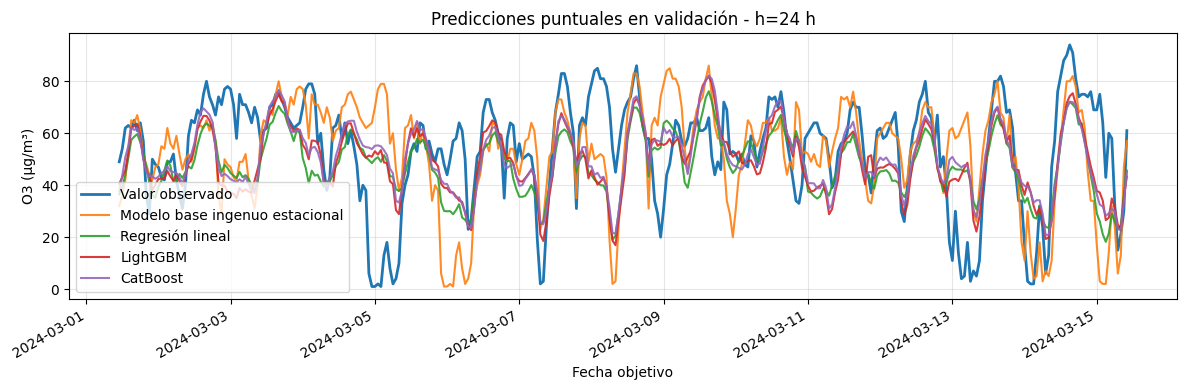

In [14]:

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    example_block["target_timestamp"],
    example_block["y_true"],
    label="Valor observado",
    linewidth=2,
    color=OBSERVED_COLOR,
)

for model_id in MODEL_ORDER:
    ax.plot(
        example_block["target_timestamp"],
        example_block[f"y_pred_{model_id}"],
        label=MODEL_REGISTRY[model_id]["display_name"],
        color=MODEL_REGISTRY[model_id]["color"],
        alpha=0.9,
    )

ax.set_title(f"Predicciones puntuales en validación - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel("O3 (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()

zoom_overlay_path = REPORTS_FIGURES_DIR / f"fig_point_predictions_overlay_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(zoom_overlay_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {zoom_overlay_path}")
plt.show()



## Figura 4 - Comparativa individual de cada modelo frente al valor observado

Para facilitar la lectura de la imagen anterior, se dibuja un panel independiente por modelo.


Figura guardada en: c:\trabajo_github\reports\figures\fig_point_predictions_small_multiples_h24.png


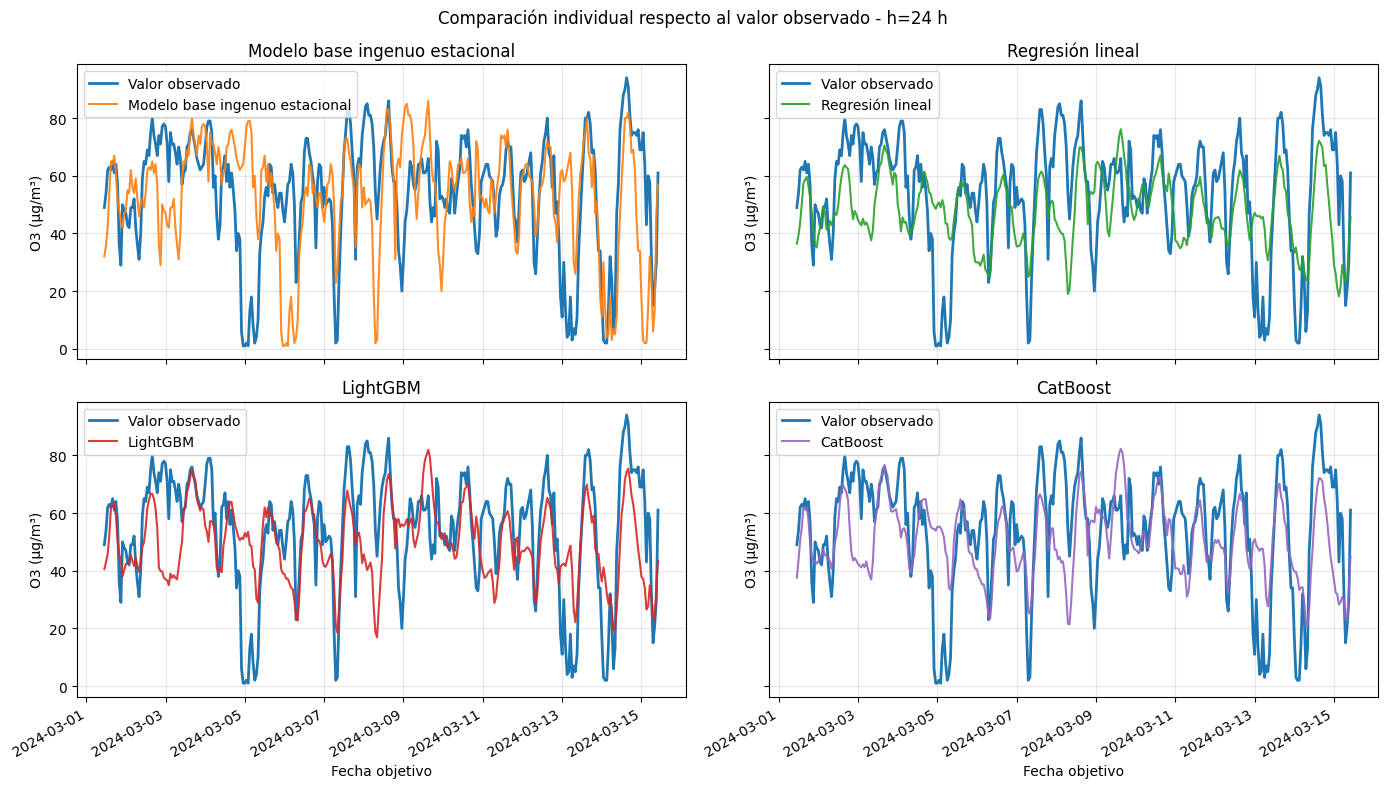

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model_id in zip(axes, MODEL_ORDER):
    color = MODEL_REGISTRY[model_id]["color"]
    label = MODEL_REGISTRY[model_id]["display_name"]

    ax.plot(
        example_block["target_timestamp"],
        example_block["y_true"],
        label="Valor observado",
        linewidth=2,
        color=OBSERVED_COLOR,
    )
    ax.plot(
        example_block["target_timestamp"],
        example_block[f"y_pred_{model_id}"],
        label=label,
        color=color,
        alpha=0.9,
    )

    ax.set_title(label)
    ax.set_ylabel("O3 (µg/m³)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

for ax in axes[2:]:
    ax.set_xlabel("Fecha objetivo")

fig.suptitle(f"Comparación individual respecto al valor observado - h={EXAMPLE_HORIZON} h")
fig.autofmt_xdate()
fig.tight_layout()

small_multiples_path = REPORTS_FIGURES_DIR / f"fig_point_predictions_small_multiples_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(small_multiples_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {small_multiples_path}")
plt.show()



## Figura 5 - Error absoluto por modelo

Además de comparar las trayectorias, conviene visualizar el error absoluto "punto a punto". Esta figura permite identificar con claridad en qué episodios falla más cada modelo.

Figura guardada en: c:\trabajo_github\reports\figures\fig_point_abs_error_small_multiples_h24.png


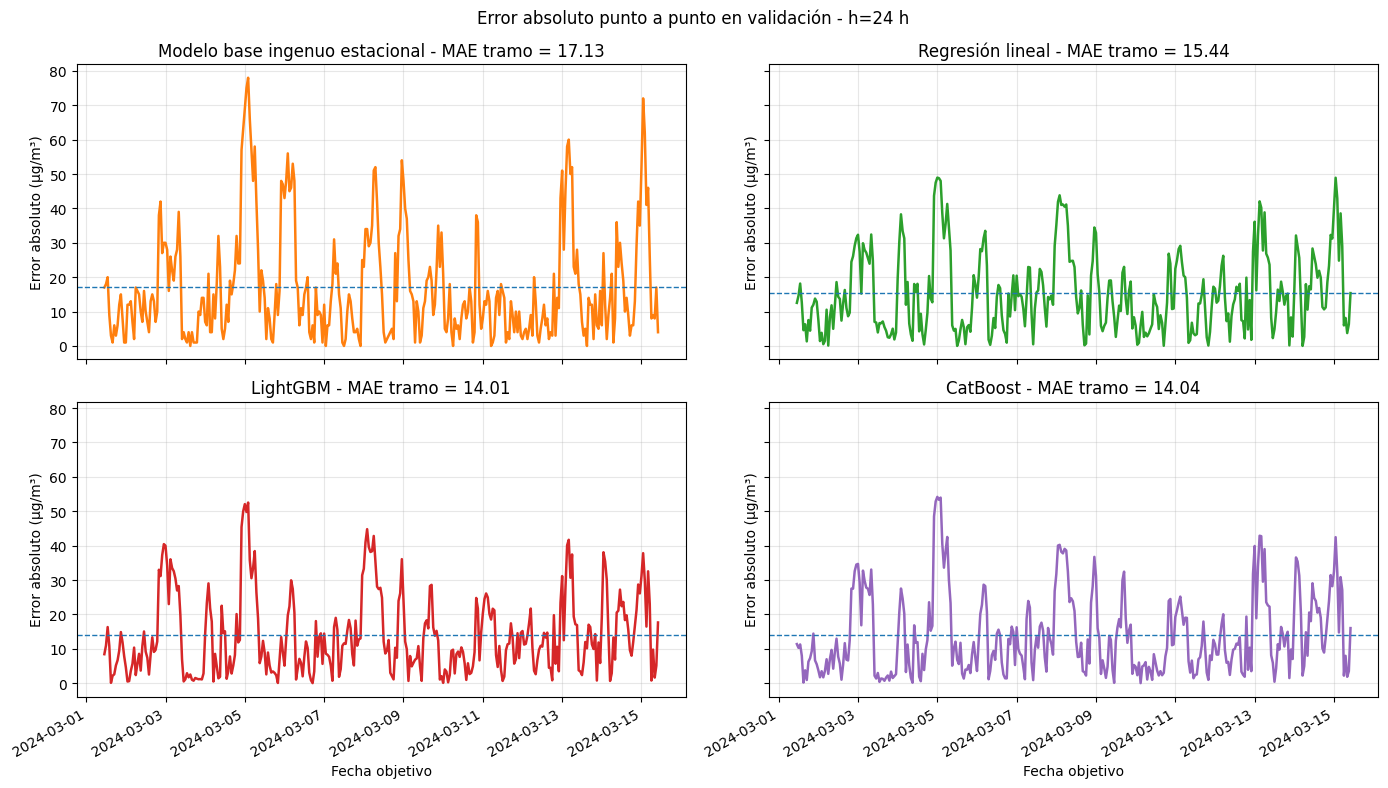

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model_id in zip(axes, MODEL_ORDER):
    label = MODEL_REGISTRY[model_id]["display_name"]
    color = MODEL_REGISTRY[model_id]["color"]
    abs_error = (example_block["y_true"] - example_block[f"y_pred_{model_id}"]).abs()
    block_mae = float(abs_error.mean())

    ax.plot(
        example_block["target_timestamp"],
        abs_error,
        color=color,
        linewidth=1.8,
    )
    ax.axhline(block_mae, linestyle="--", linewidth=1)
    ax.set_title(f"{label} - MAE tramo = {block_mae:.2f}")
    ax.set_ylabel("Error absoluto (µg/m³)")
    ax.grid(True, alpha=0.3)

for ax in axes[2:]:
    ax.set_xlabel("Fecha objetivo")

fig.suptitle(f"Error absoluto punto a punto en validación - h={EXAMPLE_HORIZON} h")
fig.autofmt_xdate()
fig.tight_layout()

abs_error_path = REPORTS_FIGURES_DIR / f"fig_point_abs_error_small_multiples_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(abs_error_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {abs_error_path}")
plt.show()



## Figura 6 - Diferencia entre las predicciones de LightGBM y CatBoost

Es importante mencionar que esta figura no compara ambos modelos con el valor observado; lo que representa es el desacuerdo entre sus predicciones para los mismos instantes objetivo. Por eso la magnitud mostrada es la diferencia absoluta entre ambas predicciones, resumida mediante la media y la mediana.


Figura guardada en: c:\trabajo_github\reports\figures\fig_lightgbm_catboost_prediction_difference.png


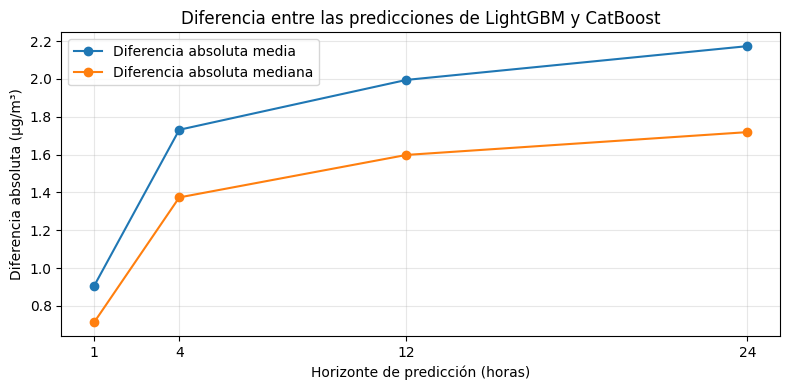

In [17]:

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    lightgbm_catboost_comparison_df["horizon"],
    lightgbm_catboost_comparison_df["mean_abs_diff"],
    marker="o",
    label="Diferencia absoluta media",
)
ax.plot(
    lightgbm_catboost_comparison_df["horizon"],
    lightgbm_catboost_comparison_df["median_abs_diff"],
    marker="o",
    label="Diferencia absoluta mediana",
)

ax.set_title("Diferencia entre las predicciones de LightGBM y CatBoost")
ax.set_xlabel("Horizonte de predicción (horas)")
ax.set_ylabel("Diferencia absoluta (µg/m³)")
ax.set_xticks(HORIZONS)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

lgbm_catboost_figure_path = REPORTS_FIGURES_DIR / "fig_lightgbm_catboost_prediction_difference.png"
fig.savefig(lgbm_catboost_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {lgbm_catboost_figure_path}")
plt.show()



## Comprobaciones finales

Como cierre, se imprimen algunas verificaciones básicas para asegurar que las tablas y las figuras clave se han generado correctamente.


In [18]:

assert not common_metrics_df.empty, "La tabla de métricas comunes está vacía."
assert target_consistency_df["is_consistent"].all(), "Se han detectado incoherencias en y_true entre modelos."
assert len(example_block) > 0, "No se ha podido construir el tramo de inspección visual."

print("Resumen final")
print("- Métricas comunes disponibles:", len(common_metrics_df))
print("- Tabla de mejora relativa disponible:", len(improvement_df))
print("- Tramo visual seleccionado:", len(example_block), "filas")
print("- Figuras generadas:")
print(f"{metrics_figure_path.name}")
print(f"{improvement_figure_path.name}")
print(f"{zoom_overlay_path.name}")
print(f"{small_multiples_path.name}")
print(f"{abs_error_path.name}")
print(f"{lgbm_catboost_figure_path.name}")


Resumen final
- Métricas comunes disponibles: 16
- Tabla de mejora relativa disponible: 16
- Tramo visual seleccionado: 336 filas
- Figuras generadas:
fig_point_metrics_validation_common.png
fig_point_improvement_vs_baseline.png
fig_point_predictions_overlay_h24.png
fig_point_predictions_small_multiples_h24.png
fig_point_abs_error_small_multiples_h24.png
fig_lightgbm_catboost_prediction_difference.png
